In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.utils import resample

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/The1OGShaggy/pyMAISE_VarianceReductionBiasMitigationFinal/refs/heads/main/chf_combined.csv")
df_lhs = pd.read_csv("https://raw.githubusercontent.com/The1OGShaggy/pyMAISE_VarianceReductionBiasMitigationFinal/refs/heads/main/lhs_samples.csv")
df_random_samples = pd.read_csv("https://raw.githubusercontent.com/The1OGShaggy/pyMAISE_VarianceReductionBiasMitigationFinal/refs/heads/main/random_samples.csv")
df_multi_stratified = pd.read_csv("https://raw.githubusercontent.com/The1OGShaggy/pyMAISE_VarianceReductionBiasMitigationFinal/refs/heads/main/multi_stratified_samples.csv")

#check that all datasets loaded properly
print("Combined dataset shape:", df.shape)
print("LHS samples shape:", df_lhs.shape)
print("Multi-stratified samples shape:", df_multi_stratified.shape)
print("Random samples shape:", df_random_samples.shape)
print("All datasets loaded successfully!")

Combined dataset shape: (2500, 7)
LHS samples shape: (1000, 7)
Multi-stratified samples shape: (1267, 7)
Random samples shape: (1000, 7)
All datasets loaded successfully!


In [3]:
#Get Target 
target = "CHF (kW m-2)"
features = [col for col in df.columns if col != target]

In [4]:
#Train Test Split
X = df[features]
y = df[target]
#80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#Latin Hypercube
X_lhs = df_lhs[features]
y_lhs = df_lhs[target]
#80/20
X_train_lhs, X_test_lhs, y_train_lhs, y_test_lhs = train_test_split(
    X_lhs, y_lhs, test_size=0.2, random_state=42
)
#Stratified Sampling
X_str = df_multi_stratified[features]
y_str = df_multi_stratified[target]

X_train_multi_stratified, X_test_multi_stratified, y_train_multi_stratified, y_test_multi_stratified = train_test_split(
    X_str, y_str, test_size=0.2, random_state=42
)

print("Train Test Split Finished")

#Bootstrapping
X_train_boot, y_train_boot = resample(
    X_train, y_train,
    replace=True,
    n_samples=len(X_train),
    random_state=42
)

X_train_lhs_boot, y_train_lhs_boot = resample(
    X_train_lhs, y_train_lhs,
    replace=True,
    n_samples=len(X_train_lhs),
    random_state=42
)

X_train_multi_boot, y_train_multi_boot = resample(
    X_train_multi_stratified, y_train_multi_stratified,
    replace=True,
    n_samples=len(X_train_multi_stratified),
    random_state=42
)

Train Test Split Finished


In [5]:
#Preproccessing and Model Pipeline
numeric_features = features

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ]
)

In [6]:
#Basic Model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Goofy Model #1
model_Goofy1 = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(256, 2, 256, 3),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Goofy Model #2
model_Goofy2 = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(16, 15, 14, 13, 12, 11, 10, 9, 8, 7 ,6, 5, 4),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])
#Boot strapped Goofy Model #1
model_boot_Goofy1 = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(256, 2, 256, 3),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#Boot Strapped Goofy Model #2
model_boot_Goofy2 = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(16, 15, 14, 13, 12, 11, 10, 9, 8, 7 ,6, 5, 4),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

#One More Goofy Model
model_Boot_Goofy3 = Pipeline([
    ("preprocessor", preprocessor),
    ("nn", MLPRegressor(
        hidden_layer_sizes=(3, 5, 7, 11, 13, 17),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

In [7]:
model.fit(X_train, y_train)
model.fit(X_train_lhs, y_train_lhs)
model.fit(X_train_multi_stratified, y_train_multi_stratified)
#Train Wide Model
model_Goofy1.fit(X_train, y_train)
model_Goofy1.fit(X_train_lhs, y_train_lhs)
model_Goofy1.fit(X_train_multi_stratified, y_train_multi_stratified)
#Train Shallow Model
model_Goofy2.fit(X_train, y_train)
model_Goofy2.fit(X_train_lhs, y_train_lhs)
model_Goofy2.fit(X_train_multi_stratified, y_train_multi_stratified)
#BootStrapping
model_boot_Goofy1.fit(X_train_boot, y_train_boot)
model_boot_Goofy1.fit(X_train_lhs_boot, y_train_lhs_boot)
model_boot_Goofy1.fit(X_train_multi_boot, y_train_multi_boot)

model_boot_Goofy2.fit(X_train_boot, y_train_boot)
model_boot_Goofy2.fit(X_train_lhs_boot, y_train_lhs_boot)
model_boot_Goofy2.fit(X_train_multi_boot, y_train_multi_boot)

model_Boot_Goofy3.fit(X_train_boot, y_train_boot)
model_Boot_Goofy3.fit(X_train_lhs_boot, y_train_lhs_boot)
model_Boot_Goofy3.fit(X_train_multi_boot, y_train_multi_boot)
print("All Models Trained!")

c:\Users\morto\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\morto\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\morto\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\morto\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the 

All Models Trained!



Neural Network Regression Results
---------------------------------
MSE : 382384.7300237739
RMSE: 618.3726465682113
MAE : 391.22179918921705
R^2 : 0.8394810297655115


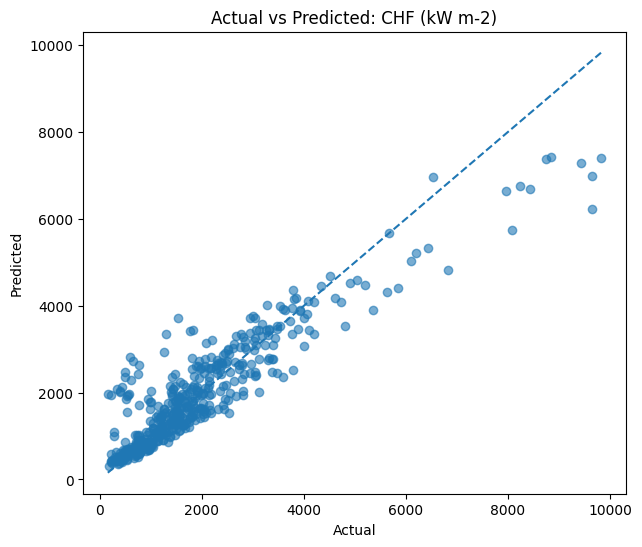

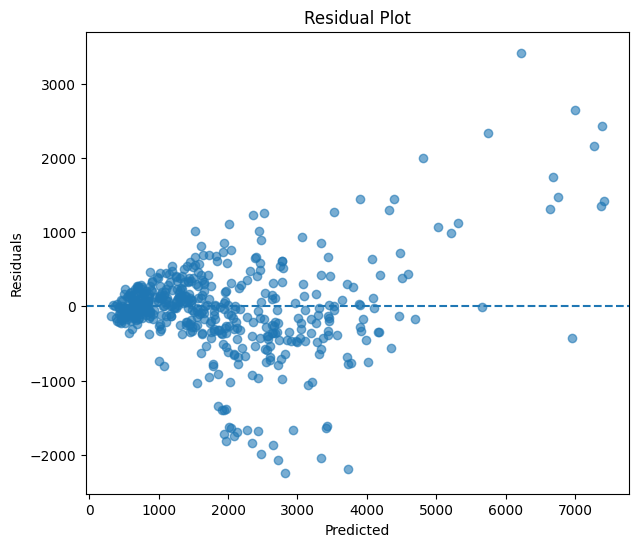

In [8]:
#Pred
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nNeural Network Regression Results")
print("---------------------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R^2 :", r2)

#Plot actual vs predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted: {target}")

#Ideal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()

#Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(7, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


Goofy#1 Neural Network Results
---------------------------------
MSE : 78343.91695495382
RMSE: 279.8998337887213
MAE : 178.8993312919838
R^2 : 0.9671124815236121


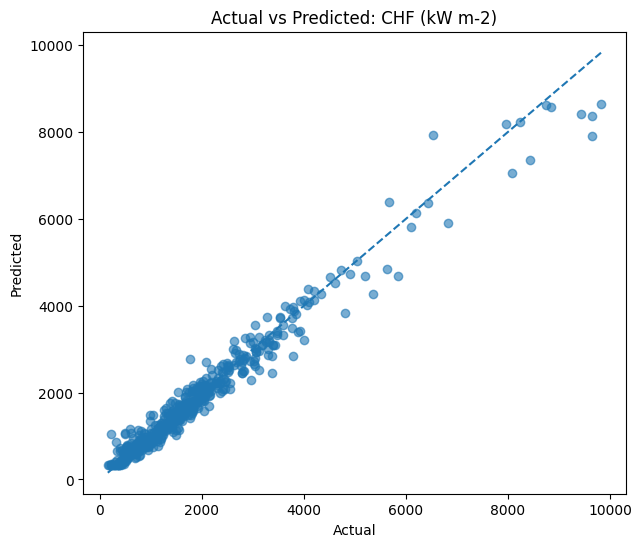

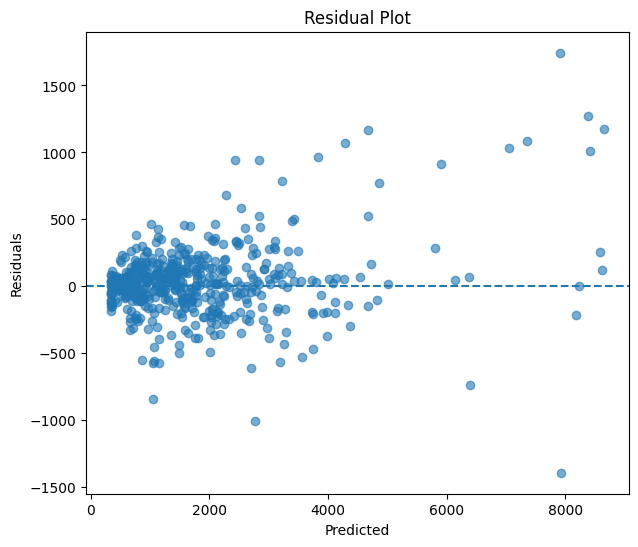

In [9]:
#Pred
y_pred = model_Goofy1.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nGoofy#1 Neural Network Results")
print("---------------------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R^2 :", r2)

#Plot actual vs predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted: {target}")

#Ideal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()

#Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(7, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


Goofy#2 Neural Network Results
---------------------------------
MSE : 107156.08961531139
RMSE: 327.34704766548816
MAE : 218.02133813178665
R^2 : 0.9550175940385095


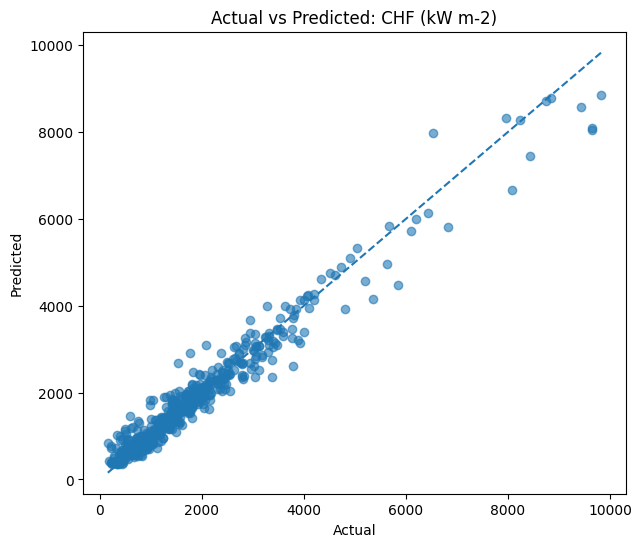

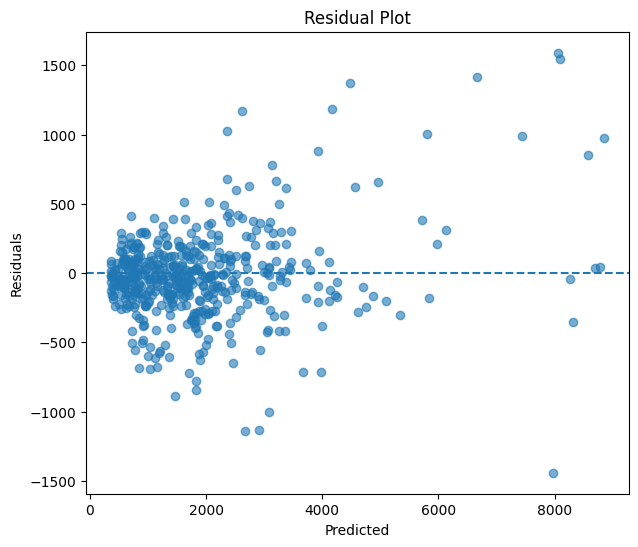

In [14]:
#Pred
y_pred = model_Goofy2.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nGoofy#2 Neural Network Results")
print("---------------------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R^2 :", r2)

#Plot actual vs predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted: {target}")

#Ideal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()

#Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(7, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


Boot Goofy#1 Neural Network Results
---------------------------------
MSE : 72912.75297265849
RMSE: 270.0236155832643
MAE : 178.29291174987003
R^2 : 0.9693923969625955


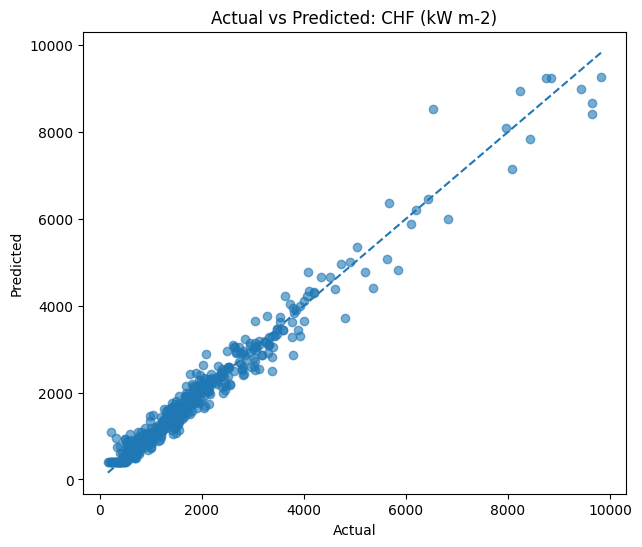

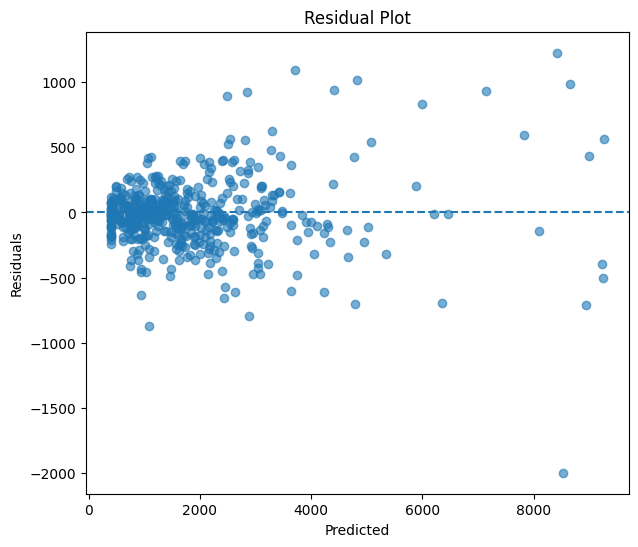

In [15]:
#Pred
y_pred = model_boot_Goofy1.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nBoot Goofy#1 Neural Network Results")
print("---------------------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R^2 :", r2)

#Plot actual vs predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted: {target}")

#Ideal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()

#Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(7, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


Boot Goofy#2 Neural Network Results
---------------------------------
MSE : 127086.82283588362
RMSE: 356.49238818785966
MAE : 238.09933895951616
R^2 : 0.9466509922330827


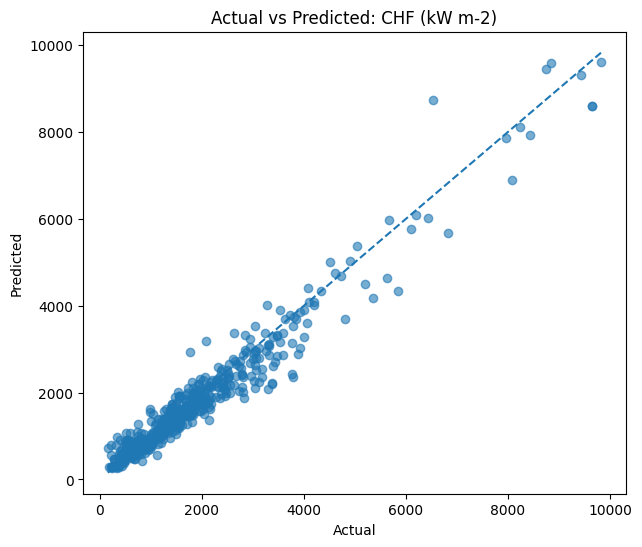

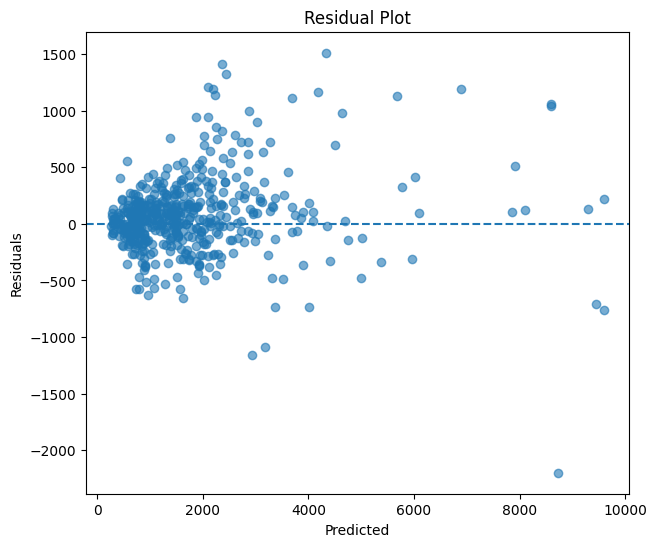

In [16]:
#Pred
y_pred = model_boot_Goofy2.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nBoot Goofy#2 Neural Network Results")
print("---------------------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R^2 :", r2)

#Plot actual vs predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted: {target}")

#Ideal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()

#Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(7, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


Boot Goofy#3 Neural Network Results
---------------------------------
MSE : 462693.6751813464
RMSE: 680.2159033581518
MAE : 475.1370075134489
R^2 : 0.805768623999439


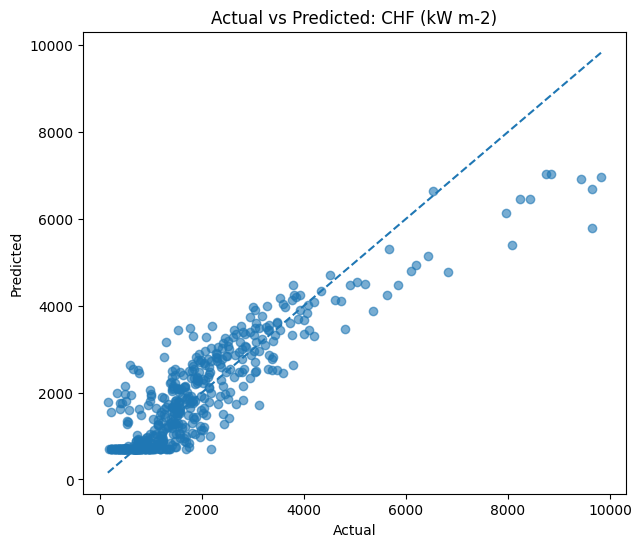

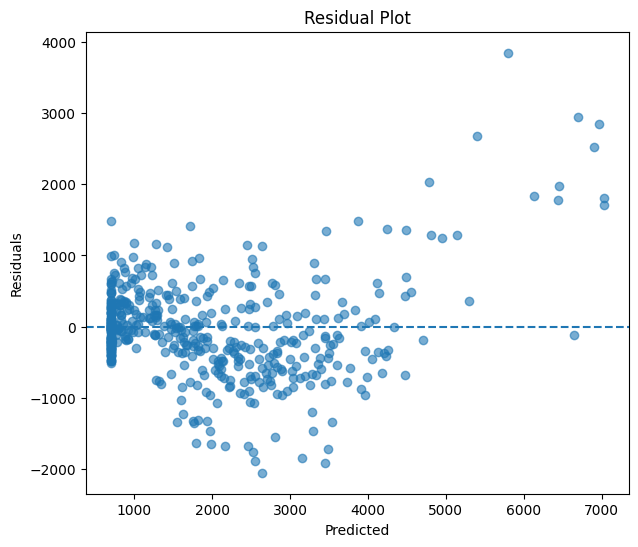

In [17]:
#Pred
y_pred = model_Boot_Goofy3.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nBoot Goofy#3 Neural Network Results")
print("---------------------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R^2 :", r2)

#Plot actual vs predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Actual vs Predicted: {target}")

#Ideal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.show()

#Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(7, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()